In [119]:
from sklearn.model_selection import train_test_split  
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [120]:
from ucimlrepo import fetch_ucirepo 
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 

In [121]:
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y_txt = breast_cancer_wisconsin_diagnostic.data.targets 

In [122]:
X.tail()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [123]:
mapping = {'M': 1, 'B': 0}
y = y_txt['Diagnosis'].map(mapping)
# y = y.to_frame(name='Diagnosis')
y.tail()

564    1
565    1
566    1
567    1
568    0
Name: Diagnosis, dtype: int64

In [124]:
train_ratio = 0.75
validation_ratio = 0.15
test_ratio = 0.10

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_ratio)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=test_ratio / (test_ratio + validation_ratio))

# Print the shapes of the resulting datasets
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (426, 30)
X_val shape: (85, 30)
X_test shape: (58, 30)


In [125]:
# Review the first few rows of the training data
print("First few rows of X_train:\n", X_train[:5])
print("First few rows of y_train:\n", y_train[:5])
print("First few rows of x_test:\n", X_test[:5])
print("First few rows of y_test:\n", y_test[:5])


First few rows of X_train:
      radius1  texture1  perimeter1  area1  smoothness1  compactness1  \
392   15.490     19.97      102.40  744.7      0.11600       0.15620   
263   15.610     19.38      100.00  758.6      0.07840       0.05616   
3     11.420     20.38       77.58  386.1      0.14250       0.28390   
557    9.423     27.88       59.26  271.3      0.08123       0.04971   
86    14.480     21.46       94.25  648.2      0.09444       0.09947   

     concavity1  concave_points1  symmetry1  fractal_dimension1  ...  radius3  \
392     0.18910          0.09113     0.1929             0.06744  ...    21.20   
263     0.04209          0.02847     0.1547             0.05443  ...    17.91   
3       0.24140          0.10520     0.2597             0.09744  ...    14.91   
557     0.00000          0.00000     0.1742             0.06059  ...    10.49   
86      0.12040          0.04938     0.2075             0.05636  ...    16.21   

     texture3  perimeter3   area3  smoothness3  comp

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create and train the LogisticRegression model
log_reg = LogisticRegression(max_iter=30, solver='liblinear', random_state=42) #  'liblinear', 'lbfgs', 'newton-cg', 'sag', 'saga'
log_reg.fit(X_train, y_train)

# exagerar las iteraciones para que este diga qué iteraciones se usaron y así ajustar el max_iter.
print("Iteraciones reales usadas:", log_reg.n_iter_[0]) 


Iteraciones reales usadas: 26


In [127]:
from sklearn.tree import DecisionTreeClassifier  

clf = DecisionTreeClassifier()  
clf.fit(X_train, y_train)  

DecisionTreeClassifier()

In [128]:
from sklearn.ensemble import RandomForestClassifier

# Create and train the RandomForestClassifier
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)


RandomForestClassifier()

In [129]:
from sklearn.svm import SVC

# Create and train the SVM model
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)


SVC(kernel='linear')

---

In [130]:
def plot_confusion_matrix(y_true, y_predicted, model_name):
    """
    Visualiza la matriz de confusión.

    Args:
        y_true (array-like): Las etiquetas verdaderas.
        y_predicted (array-like): Las etiquetas predichas por el modelo.
        model_name (str): El nombre del modelo utilizado para las predicciones.
    """
    cm = confusion_matrix(y_true, y_predicted)
    plt.figure(figsize=(4, 2))  # Ajusté un poco el tamaño para mejor visualización
    class_names = ['Benigno', 'Maligno'] # 0 , 1
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

Accuracy (Logistic Regression): 1.0


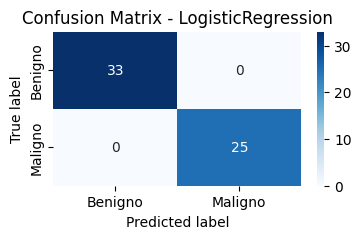

Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        25

    accuracy                           1.00        58
   macro avg       1.00      1.00      1.00        58
weighted avg       1.00      1.00      1.00        58



In [131]:
# Predict using the LogisticRegression
y_pred_lr = log_reg.predict(X_test)

# Evaluate the LogisticRegression
print("Accuracy (Logistic Regression):", accuracy_score(y_test, y_pred_lr))
plot_confusion_matrix(y_test, y_pred_lr,"LogisticRegression")
print("Classification Report (Logistic Regression):\n", classification_report(y_test, y_pred_lr))

Accuracy (Random Forest): 1.0


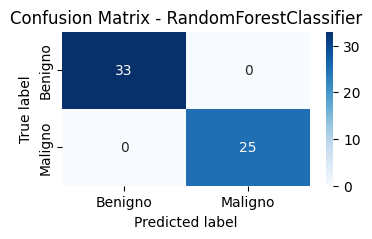

Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        25

    accuracy                           1.00        58
   macro avg       1.00      1.00      1.00        58
weighted avg       1.00      1.00      1.00        58



In [132]:
# Predict using the RandomForestClassifier with validation set
y_pred_rf = rf_clf.predict(X_test)
# Evaluate the RandomForestClassifier
print("Accuracy (Random Forest):", accuracy_score(y_test, y_pred_rf))
plot_confusion_matrix(y_test, y_pred_rf,"RandomForestClassifier")
print("Classification Report (Random Forest):\n", classification_report(y_test, y_pred_rf))

Accuracy (SVM): 1.0


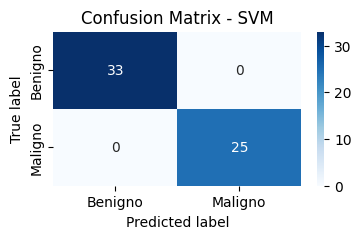

Classification Report (SVM):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        25

    accuracy                           1.00        58
   macro avg       1.00      1.00      1.00        58
weighted avg       1.00      1.00      1.00        58



In [133]:
# Predict using the SVM model
y_pred_svm = svm_model.predict(X_test)

# Evaluate the SVM model
print("Accuracy (SVM):", accuracy_score(y_test, y_pred_svm))
plot_confusion_matrix(y_test, y_pred_svm,"SVM")
print("Classification Report (SVM):\n", classification_report(y_test, y_pred_svm))

Accuracy (Decision Tree): 0.9482758620689655


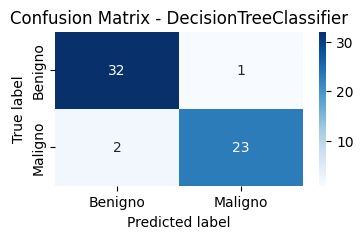

Classification Report (Decision Tree):
               precision    recall  f1-score   support

           0       0.94      0.97      0.96        33
           1       0.96      0.92      0.94        25

    accuracy                           0.95        58
   macro avg       0.95      0.94      0.95        58
weighted avg       0.95      0.95      0.95        58



In [134]:
# predict using the DecisionTreeClassifier  
y_pred = clf.predict(X_test)  
print("Accuracy (Decision Tree):", accuracy_score(y_test, y_pred)) 
plot_confusion_matrix(y_test, y_pred,"DecisionTreeClassifier")
print("Classification Report (Decision Tree):\n", classification_report(y_test, y_pred))


➡️ Matriz de confusión a mano (del último, Decision Tree)

In [135]:
# Number of classes
num_classes = y.nunique()
print("Number of classes:", num_classes)

# Initialize confusion matrix
manual_cm = [[0] * num_classes for _ in range(num_classes)]

# Populate the confusion matrix
for true_label, pred_label in zip(y_test, y_pred):
    manual_cm[true_label][pred_label] += 1

# Print the confusion matrix
print("Manually computed confusion matrix:")
for row in manual_cm:
    print(row)

Number of classes: 2
Manually computed confusion matrix:
[32, 1]
[2, 23]
